# Data Preparation
- Ingesting dataset from kaggle. The data set is a anime-and-manga dataset of 30k records. The anime dataset is fro MyAnimeList.
- Performing data manipulation, processing and EDA.

In [1]:
# importing libraries
import kagglehub
from pathlib import Path
import shutil
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

c:\Users\sharm\anaconda3\envs\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Ingestion

In [ ]:
# Downloading dataset
dataset_name = "patelris/anime-and-manga-dataset-2026"
cache = Path(kagglehub.dataset_download(dataset_name))

In [ ]:
# project data directory
dest = Path("../data")
dest.mkdir(parents=True, exist_ok=True)

# 3. Source path
src = cache / "anime_dataset.csv" if cache.is_dir() else cache

# 4. Copy file
shutil.copy2(src, dest / "anime_dataset.csv")

# 5. Delete cache folder
shutil.rmtree(cache, ignore_errors=True)

print(f"Saved to: {dest.resolve() / 'anime_dataset.csv'}")


Saved to: D:\Sanctum\quest\forge\anime-rating-predictor\data\anime_dataset.csv


## Data Preprocessing

In [94]:
# Importing dataset as a DataFrame
df = pd.read_csv("../data/anime_dataset.csv")

In [95]:
# Data Look
print(f"Top five records:")
df.head(5)

Top five records:


,mal_id,title,title_english,title_japanese,type,source,episodes,status,airing,aired_from,...,season,year,studios,producers,licensors,genres,themes,demographics,synopsis,image_url
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,TV,Original,26.0,Finished Airing,False,1998-04-03,...,spring,1998.0,Sunrise,Bandai Visual|Victor Entertainment|Audio Plann...,Funimation,Action|Award Winning|Sci-Fi,Adult Cast|Space,NaN,"Crime is timeless. By the year 2071, humanity ...",https://myanimelist.net/images/anime/4/19644.jpg
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,Movie,Original,1.0,Finished Airing,False,2001-09-01,...,NaN,NaN,Bones,Sunrise|Bandai Visual,Sony Pictures Entertainment|Funimation,Action|Sci-Fi,Adult Cast|Space,NaN,"Another day, another bounty—such is the life o...",https://myanimelist.net/images/anime/1439/9348...
2,6,Trigun,Trigun,トライガン,TV,Manga,26.0,Finished Airing,False,1998-04-01,...,spring,1998.0,Madhouse,Victor Entertainment|Arts Pro,Funimation,Action|Adventure|Sci-Fi,Adult Cast,Shounen,"Vash the Stampede is the man with a $$60,000,0...",https://myanimelist.net/images/anime/1130/1200...
3,7,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,Original,26.0,Finished Airing,False,2002-07-03,...,summer,2002.0,Sunrise,Bandai Visual|Dentsu|Victor Entertainment,Funimation|Bandai Entertainment,Action|Drama|Mystery|Supernatural,Detective,NaN,"Though hidden away from the general public, Wi...",https://myanimelist.net/images/anime/10/19969.jpg
4,8,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,TV,Manga,52.0,Finished Airing,False,2004-09-30,...,fall,2004.0,Toei Animation,TV Tokyo|Dentsu,Illumitoon Entertainment,Action|Adventure|Fantasy,NaN,Shounen,It is the dark century and the people are suff...,https://myanimelist.net/images/anime/7/21569.jpg


In [96]:
# Data Overview
print("\nInformation about the anime dataset")
df.info()


Information about the anime dataset
<class 'pandas.DataFrame'>
RangeIndex: 30075 entries, 0 to 30074
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mal_id          30075 non-null  int64  
 1   title           30075 non-null  str    
 2   title_english   13306 non-null  str    
 3   title_japanese  29951 non-null  str    
 4   type            30003 non-null  str    
 5   source          30075 non-null  str    
 6   episodes        29236 non-null  float64
 7   status          30075 non-null  str    
 8   airing          30075 non-null  bool   
 9   aired_from      29166 non-null  str    
 10  aired_to        11594 non-null  str    
 11  duration        30075 non-null  str    
 12  rating          29473 non-null  str    
 13  score           19892 non-null  float64
 14  scored_by       19892 non-null  float64
 15  rank            22584 non-null  float64
 16  popularity      30075 non-null  int64  
 17  membe

### Observation:
- There are `30075` records and `28` features.
- Features Information

  - `mal_id`: My Anime List official unique id.
  
  - `title/title_english/title_japanese`: Name of anime the official one, in english and japanese.
  - `type`: Type of anime.
  - `source`: Source material of anime.
  - `episodes`; Total episodes 
  - `status`: Status of anime whether it is airing or completed.
  - `airing`: Airing status.
  - `aired_from`/`aired_to`: Anime starting airing and ending date.
  - `duration`:Each episode duration.
  - `rating`: Content Rating of anime.
  - `score`: Score given by user.
  - `scored_by`: No. of viewer scored the anime.
  - `rank`: Rank of the anime in MAL.
  - `popularity`: Popularity ranking.
  - `members`: MAL members number.
  - `favorites`: No. of people mark as favorites.
  - `season`: Airing season.
  - `year`: Airing Year.
  - `studios`: Anime studio that produce it.
  - `producers`: Anime producers.
  - `licensors`: Studio that has the license to air this anime.
  - `genres`: Anime genre.
  - `themes`: Themes of anime.
  - `demographic`: Demographics of the anime. Content rating categories of anime.
  - `synopsis`: Synopsis of anime.
  - `image_url`: Cover image url.

In [97]:
# Dropping redundant and non-predictive features
col = ["scored_by","image_url","demographics", "licensors", "producers", "year", "members", "popularity", "rank", "favorites", "aired_to", "airing", "status", "title_english", "title_japanese", "mal_id"]
dfc = df.drop(columns=col)

In [98]:
# Feature Metadata
def df_metadata(df):
    """Metadata of the features in df: Cardinality, Missing, Duplicates.
    """
    summary = {}
    total_rows = df.shape[0]
        
    for col in df.columns:
        # missing values in a column
        missing = df[col].isnull().sum()
        # unique value in a column excluding nan
        unique = df[col].nunique(dropna=False)
        
        summary[col] = {
            'feature_name': col,
            'unique_value': unique,
            'null_value': missing,
            'duplicated_value': int(df[col].duplicated().sum()),
            'missing_ratio%': round((missing / total_rows) * 100, 2),
            'duplicated_ratio%': round((int(df[col].duplicated().sum()) / total_rows) * 100, 2)
        }
            
    return pd.DataFrame.from_dict(summary, orient='index').reset_index(drop=True)
    

In [99]:
meta = df_metadata(dfc)
print(f"Information of features:\n")
meta

Information of features:



,feature_name,unique_value,null_value,duplicated_value,missing_ratio%,duplicated_ratio%
0,title,29934,0,141,0.00,0.47
1,type,10,72,30065,0.24,99.97
2,source,17,0,30058,0.00,99.94
3,episodes,263,839,29812,2.79,99.13
4,aired_from,9561,909,20514,3.02,68.21
5,duration,344,0,29731,0.00,98.86
6,rating,7,602,30068,2.00,99.98
7,score,570,10183,29505,33.86,98.10
8,season,5,23550,30070,78.30,99.98
9,studios,2020,11938,28055,39.69,93.28


### Observation:
- `season` has a missing ratio of greater than 75%, safe to remove this feature.
- `title` & `synopsis` has 0.47 and 18.15 duplicated values respectively, so it is idea to remove them.

In [100]:
# removing columns with high missing values
cols = meta[meta['missing_ratio%'] > 50.0]['feature_name'].tolist()
dfc = dfc.drop(columns= cols,errors='ignore')

In [101]:
# handling columns datatype
# categorical type
dfc.type = dfc.type.astype('category')
dfc.source = dfc.source.astype('category')
dfc.rating = dfc.rating.astype('category')
# numerical type
dfc.episodes = dfc.episodes.astype('Int64')
hours = dfc['duration'].str.extract(r'(\d+)\s*hr', expand=False).fillna(0).astype(int)
mins = dfc['duration'].str.extract(r'(\d+)\s*min', expand=False).fillna(0).astype(int)
dfc['duration_mins'] = (hours * 60) + mins
dfc = dfc.drop(columns = ['duration'])
# datetime type
dfc.aired_from = pd.to_datetime(dfc['aired_from'],errors='coerce')
dfc['season'] = pd.to_datetime(df['aired_from']).dt.quarter.map({1:'winter',2:'spring',3:'summer',4:'fall'}).astype('category')
dfc = dfc.drop(columns=['aired_from'])

In [102]:
# Metadata after removing high missing ratio features
df_metadata(dfc)

,feature_name,unique_value,null_value,duplicated_value,missing_ratio%,duplicated_ratio%
0,title,29934,0,141,0.00,0.47
1,type,10,72,30065,0.24,99.97
2,source,17,0,30058,0.00,99.94
3,episodes,263,839,29812,2.79,99.13
4,rating,7,602,30068,2.00,99.98
5,score,570,10183,29505,33.86,98.10
6,studios,2020,11938,28055,39.69,93.28
7,genres,861,6394,29214,21.26,97.14
8,themes,1058,12098,29017,40.23,96.48
9,synopsis,24617,5038,5458,16.75,18.15


In [103]:
# removing values where the duration is 0
dfc = dfc[dfc['duration_mins']>0]
# removing trailer and commercial type data points not full fledge anime.
dfc = dfc[~dfc['type'].isin(['CM','PV'])]

In [104]:
# handling duplicated titles values
dfc[dfc.duplicated(subset='title', keep=False)].sort_values('title')[['title','type','episodes','synopsis','studios']]
# dropping duplicates
dfc = dfc.drop_duplicates(subset=['title'])        
dfc = dfc.drop_duplicates(subset=['synopsis'])        

In [105]:
# Removing records with multiple null values features
lst=dfc[dfc[['studios','genres','themes','score']].isna().all(axis=1)].index.to_list()
dfc.drop(index=lst,inplace=True)

In [106]:
# Organizing source and type features categories.
# Grouping `type` feature
type_map = {'TV': 'TV',
    'ONA': 'TV',
    'Movie': 'Movie',
    'OVA': 'Special',
    'TV Special': 'Special',
    'Special': 'Special',
    'Music': 'Special',}
dfc['type'] = dfc['type'].map(type_map)
# Grouping `source` feature
source_map ={
    'Original':'Original',
    'Manga':'Manga',
    'Light Novel':'Novel',
    'Visual Novel': 'Novel',
    '4-koma manga': 'Manga',
    'Novel':'Novel',
    'Other':'Other',
    'Unknown': 'Unknown',
    'Picture Book': 'Manga',
    'Web Manga': 'Manga',
    'Music':'Audio',
    'Radio':'Audio',
    'Book':'Novel',
    'Mixed media':'Mixed Media',
    'Game': 'Game',
    'Card game': 'Game',
    'Web Novel':'Novel'
}
dfc['source'] = dfc['source'].map(source_map)

In [107]:
# handling missing values
# categorical type
dfc.type = dfc.type.fillna(dfc.type.mode()[0])
dfc.source = dfc.source.fillna(dfc.source.mode()[0])
dfc.rating = dfc.rating.fillna(dfc.rating.mode()[0])
dfc.season = dfc.season.fillna(dfc.season.mode()[0])
# numerical 
dfc.episodes = dfc.episodes.fillna(int(dfc.episodes.median()))
# string
dfc.drop(dfc[dfc.synopsis.isna()].index, inplace=True)
# High Cardinality type 
dfc[['studios']] = dfc[['studios']].fillna('Unknown')
dfc[['genres']] = dfc[['genres']].fillna('Unknown')
dfc[['themes']] = dfc[['themes']].fillna('Unknown')

In [108]:
# Dropping score null 
dfc = dfc.drop(index=dfc[dfc.score.isna()].index)

In [109]:
df_metadata(dfc)

,feature_name,unique_value,null_value,duplicated_value,missing_ratio%,duplicated_ratio%
0,title,18158,0,0,0.0,0.00
1,type,3,0,18155,0.0,99.98
2,source,8,0,18150,0.0,99.96
3,episodes,203,0,17955,0.0,98.88
4,rating,6,0,18152,0.0,99.97
5,score,559,0,17599,0.0,96.92
6,studios,1694,0,16464,0.0,90.67
7,genres,831,0,17327,0.0,95.42
8,themes,974,0,17184,0.0,94.64
9,synopsis,18158,0,0,0.0,0.00


In [110]:
# handling high cardinality features
## Organizing
dfc['studio_list'] = dfc['studios'].str.split('|')
dfc['genres_list'] = dfc['genres'].str.split('|')
dfc['themes_list'] = dfc['themes'].str.split('|')
dfc = dfc.drop(columns=['studios','genres', 'themes'])
dfc = dfc.rename(columns={'studio_list':'studios','genres_list': 'genres', 'themes_list': 'themes'})

## exploding the features
exploded  = dfc['studios'].explode()
known_studios = exploded[exploded != 'Unknown']
## Setting the cutoff
studio_count = known_studios.value_counts()
top_set = set(studio_count[studio_count>=25].index)
## grouping the categories 
def simplify_group(studios):
    cleaned = [s if (s in top_set or s == 'Unknown') else 'Other' for s in studios]
    return [*dict.fromkeys(cleaned)]
dfc['studios'] = dfc['studios'].apply(simplify_group)
## Striping the missing value place holder 'Unkwown'
for col in ['studios', 'genres', 'themes']:
    dfc[col] = dfc[col].apply(lambda vals: [v for v in vals if v != 'Unknown'])

In [111]:
dfc.reset_index()

,index,title,type,source,episodes,rating,score,synopsis,duration_mins,season,studios,genres,themes
0,0,Cowboy Bebop,TV,Original,26,R - 17+ (violence & profanity),8.75,"Crime is timeless. By the year 2071, humanity ...",24,spring,[Sunrise],"[Action, Award Winning, Sci-Fi]","[Adult Cast, Space]"
1,1,Cowboy Bebop: Tengoku no Tobira,Movie,Original,1,R - 17+ (violence & profanity),8.38,"Another day, another bounty—such is the life o...",115,summer,[Bones],"[Action, Sci-Fi]","[Adult Cast, Space]"
2,2,Trigun,TV,Manga,26,PG-13 - Teens 13 or older,8.22,"Vash the Stampede is the man with a $$60,000,0...",24,spring,[Madhouse],"[Action, Adventure, Sci-Fi]",[Adult Cast]
3,3,Witch Hunter Robin,TV,Original,26,PG-13 - Teens 13 or older,7.25,"Though hidden away from the general public, Wi...",25,summer,[Sunrise],"[Action, Drama, Mystery, Supernatural]",[Detective]
4,4,Bouken Ou Beet,TV,Manga,52,PG - Children,7.01,It is the dark century and the people are suff...,23,summer,[Toei Animation],"[Action, Adventure, Fantasy]",[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18153,29896,Fashion Beat,Special,Original,1,PG-13 - Teens 13 or older,6.57,Music video for the song Fashion Beat by Miko ...,2,winter,[],[],[Music]
18154,29966,Primadonna,Special,Original,1,PG-13 - Teens 13 or older,7.16,Music video for the song Primadonna by Suisei ...,2,winter,[Other],[],[Music]
18155,30002,Re:Zero kara Hajimeru Break Time 4th Season,Special,Original,1,PG-13 - Teens 13 or older,6.91,Fourth season of Re:Zero kara Hajimeru Kyuukei...,2,spring,[Studio PuYUKAI],[Comedy],[]
18156,30017,Tsue to Tsurugi no Wistoria Recap,Special,Manga,1,PG-13 - Teens 13 or older,6.64,Recap episode of Tsue to Tsurugi no Wistoria.,23,spring,"[Actas, Bandai Namco Pictures]","[Action, Fantasy]",[School]


## Exploratory Data Analysis

### Univariate Analysis

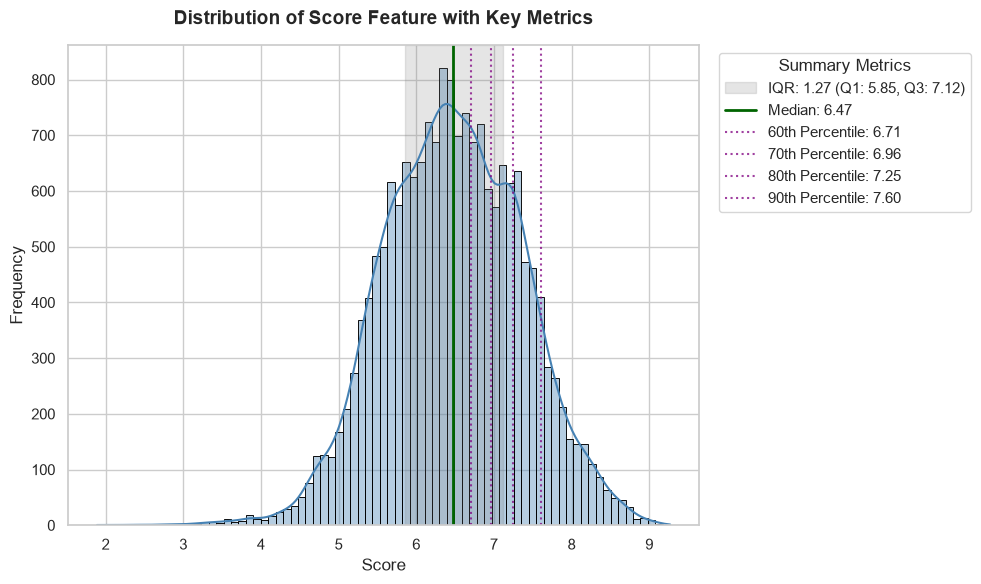

In [112]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Calculate statistics
median_val = dfc['score'].median()
q1 = dfc['score'].quantile(0.25)
q3 = dfc['score'].quantile(0.75)
iqr = q3 - q1
quantiles = [0.5, 0.6, 0.7, 0.75, 0.8, 0.9]
q_vals = dfc['score'].quantile(quantiles)

# Plotting 
sns.histplot(dfc['score'], kde=True, color='steelblue', alpha=0.4, edgecolor='black')
plt.axvspan(q1, q3, color='gray', alpha=0.2, label=f'IQR: {iqr:.2f} (Q1: {q1:.2f}, Q3: {q3:.2f})')
plt.axvline(median_val, color='darkgreen', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
for p, val in q_vals.items():
    if p not in [0.5, 0.75]:
        plt.axvline(val, color='purple', linestyle=':', linewidth=1.5, alpha=0.75,
                    label=f'{int(p * 100)}th Percentile: {val:.2f}')
        
# Labeling    
plt.title('Distribution of Score Feature with Key Metrics', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(title='Summary Metrics', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()

plt.show()

#### Observation:
- The above histogram clearly shows that more than `70%` anime has a score of `7.00`.
- The ideal threshold for the an anime to be high rated is `7.00`.

In [113]:
# setting the threshold to select if the anime is worth watching
dfc['high_rated'] = (dfc['score']>=7.0).astype(int)
dfc=dfc.drop(columns=['score'])

70.86% is high rated status anime where as 29.14%


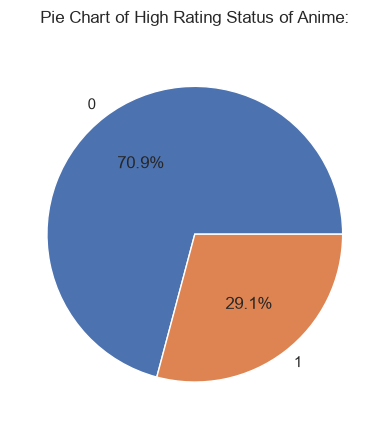

In [114]:
# Plotting high rated
status_percentage = dfc['high_rated'].value_counts(normalize=True)*100
label = ['0','1']
plt.pie(status_percentage,labels=label,autopct='%1.1f%%')
plt.title("Pie Chart of High Rating Status of Anime:\n")
print(f"{round(status_percentage[0],2)}% is high rated status anime where as {round(status_percentage[1],2)}%")

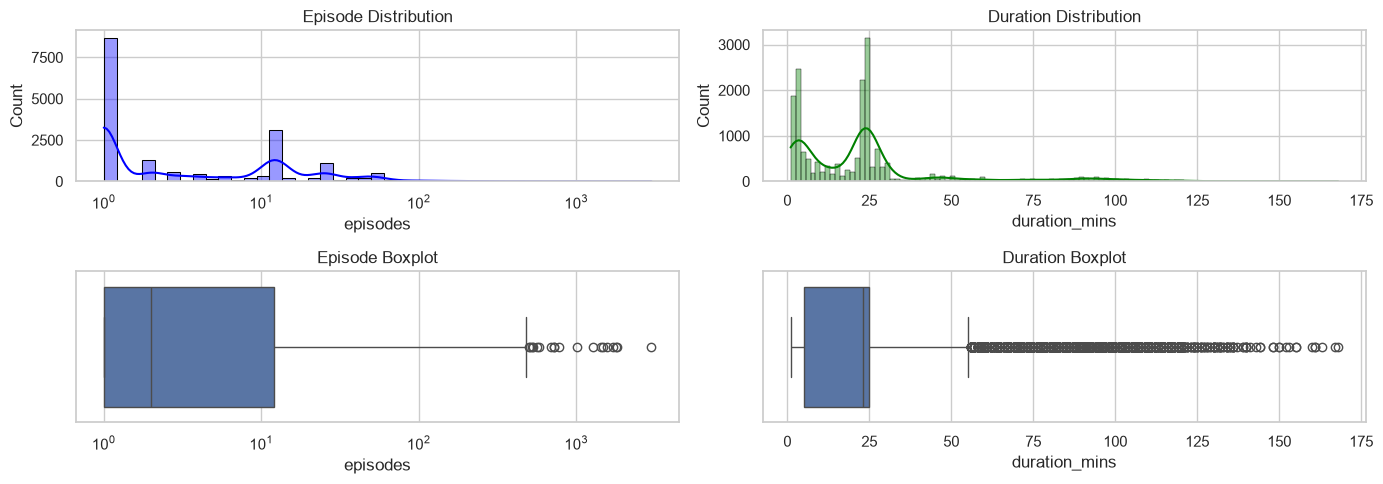

In [115]:
# Episode and Duration
fig, axes = plt.subplots(2, 2, figsize=(14, 5))

sns.histplot(dfc['episodes'], kde=True, color='blue', alpha=0.4, edgecolor='black', ax=axes[0,0],log_scale=True)
axes[0,0].set_title('Episode Distribution')
sns.histplot(dfc['duration_mins'], kde=True, color='green', alpha=0.4, edgecolor='black', ax=axes[0,1],)
axes[0,1].set_title('Duration Distribution',)

sns.boxplot(dfc['episodes'],orient='h',ax=axes[1,0],log_scale=True)
axes[1,0].set_title('Episode Boxplot')
sns.boxplot(dfc['duration_mins'],orient='h',ax=axes[1,1])
axes[1,1].set_title('Duration Boxplot')

plt.tight_layout()
plt.show()

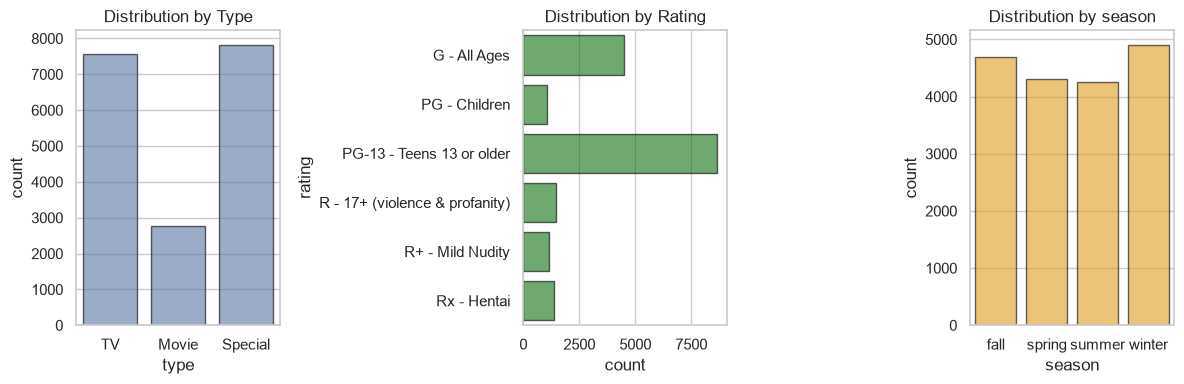

In [116]:
# type, rating, studio, season
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
## Distribution by Type
sns.countplot(data=dfc, x='type', ax=axes[0],alpha=0.6,edgecolor='black',linewidth=1)
axes[0].set_title('Distribution by Type')
## Distribution by Rating
sns.countplot(data=dfc, y='rating', ax=axes[1],color='green',alpha=0.6,edgecolor='black',linewidth=1.0 )
axes[1].set_title('Distribution by Rating')

## Distribution by season
sns.countplot(data=dfc, x='season', ax=axes[2],color='orange',alpha=0.6,edgecolor='black',linewidth=1.0)
axes[2].set_title('Distribution by season')

plt.tight_layout()
plt.show()

Text(0, 0.5, '')

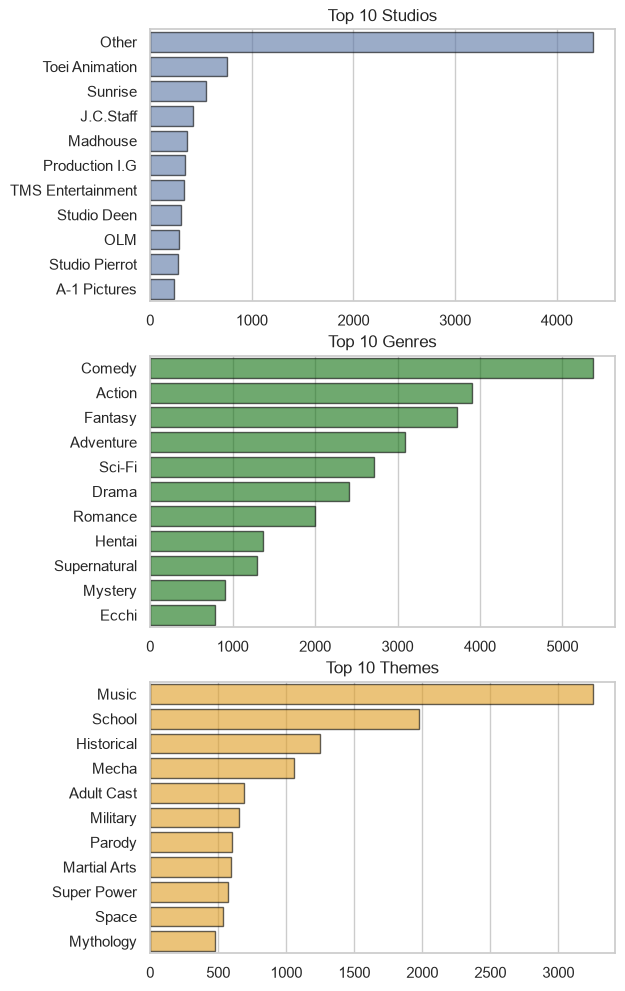

In [117]:
# studios, genres, themes
fig, axes = plt.subplots(3,1,figsize=(6,12))
# Studios
top_10_studios  =  dfc['studios'].explode().value_counts().iloc[0:11]
sns.barplot(x = top_10_studios.values,y=top_10_studios.index,ax=axes[0],alpha=0.6,edgecolor='black',linewidth=1)
axes[0].set_title('Top 10 Studios')
axes[0].set_ylabel(None)
# Genres
top_10_genres  =  dfc['genres'].explode().value_counts().iloc[0:11]
sns.barplot(x = top_10_genres.values,y=top_10_genres.index,ax=axes[1],color='green',alpha=0.6,edgecolor='black',linewidth=1)
axes[1].set_title('Top 10 Genres')
axes[1].set_ylabel(None)
# Themes
top_10_themes  =  dfc['themes'].explode().value_counts().iloc[0:11]
sns.barplot(x = top_10_themes.values,y=top_10_themes.index,ax=axes[2],color='orange',alpha=0.6,edgecolor='black',linewidth=1)
axes[2].set_title('Top 10 Themes')
axes[2].set_ylabel(None)

#### Observation:
**Numerical Feature**
- Both `episodes` and `duration_mins` are heavily right-skewed.
- Majority of the anime has only `1` episode, with some extreme anime outliers running for `500+` episodes.
- This is also reflected in anime durations as there are split between shorter anime less than `3 min` and and the ideal length of an episode approx `24 min`. With some episodes exceeding `50 min` these are the outliers indicating movies length.
**Categorical Features**:
- Majority of the records are split between `TV` & `Special` `type`. `Movies` is the smallest group among them.
- Among these records more than `7500` anime has a `Rating` of `PG-13` , with `G` for all ages coming at second place and the 
- Anime releasing quantity are almost balance across 4 `season`.
- `genres`,`studios`,`themes` each has `Unknown` value representing the missing the data point. Removing them and replacing them with a placeholder empty list. Affected anime records now show means no-info regarding that feature.
- Toei Animation is the leading `studios` with Comedy and Music taking first place for `genres` and `themes`.

### Bi-variate Analysis

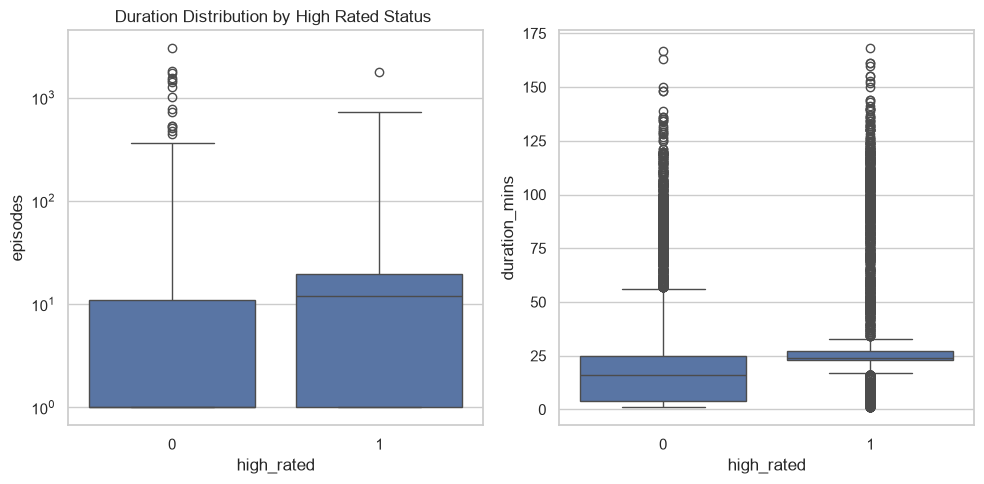

In [122]:
# episode and duration vs high_rated
fig, axes = plt.subplots(1,2, figsize=(10,5))

## Episode vs high_rated
sns.boxplot(x='high_rated',y='episodes',data=dfc,ax=axes[0],log_scale=True)
axes[0].set_title('Episode Count by High Rated Status ')

## Duration vs high_rated
sns.boxplot(x='high_rated',y='duration_mins',data=dfc,ax=axes[1])
axes[0].set_title('Duration Distribution by High Rated Status ')

plt.tight_layout()
plt.show()

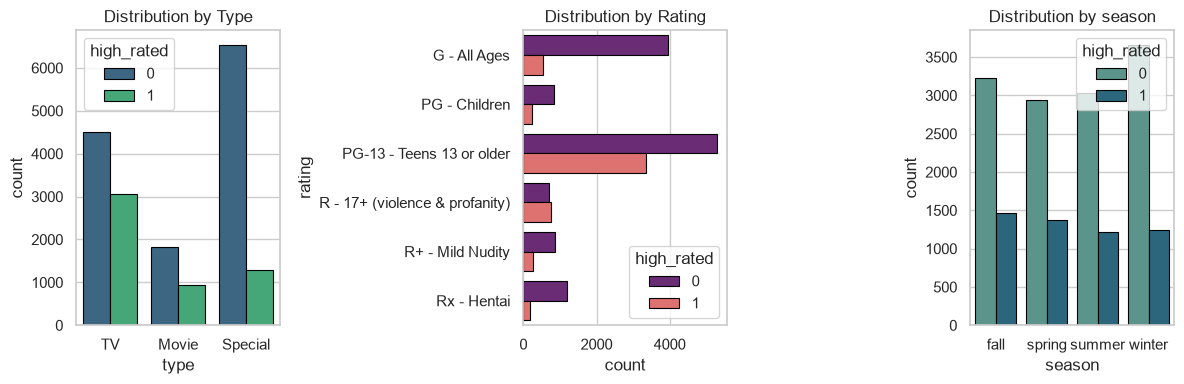

In [123]:
# type, rating, season vs high-rated status
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
## Distribution by Type
sns.countplot(data=dfc, x='type', ax=axes[0],palette='viridis', edgecolor='black', linewidth=0.8, hue='high_rated')
axes[0].set_title('Distribution by Type')
## Distribution by Rating
sns.countplot(data=dfc, y='rating', ax=axes[1],palette='magma', edgecolor='black', linewidth=0.8, hue='high_rated')
axes[1].set_title('Distribution by Rating')

## Distribution by season
sns.countplot(data=dfc, x='season', ax=axes[2],palette='crest', edgecolor='black', linewidth=0.8, hue='high_rated')
axes[2].set_title('Distribution by season')

plt.tight_layout()
plt.show()

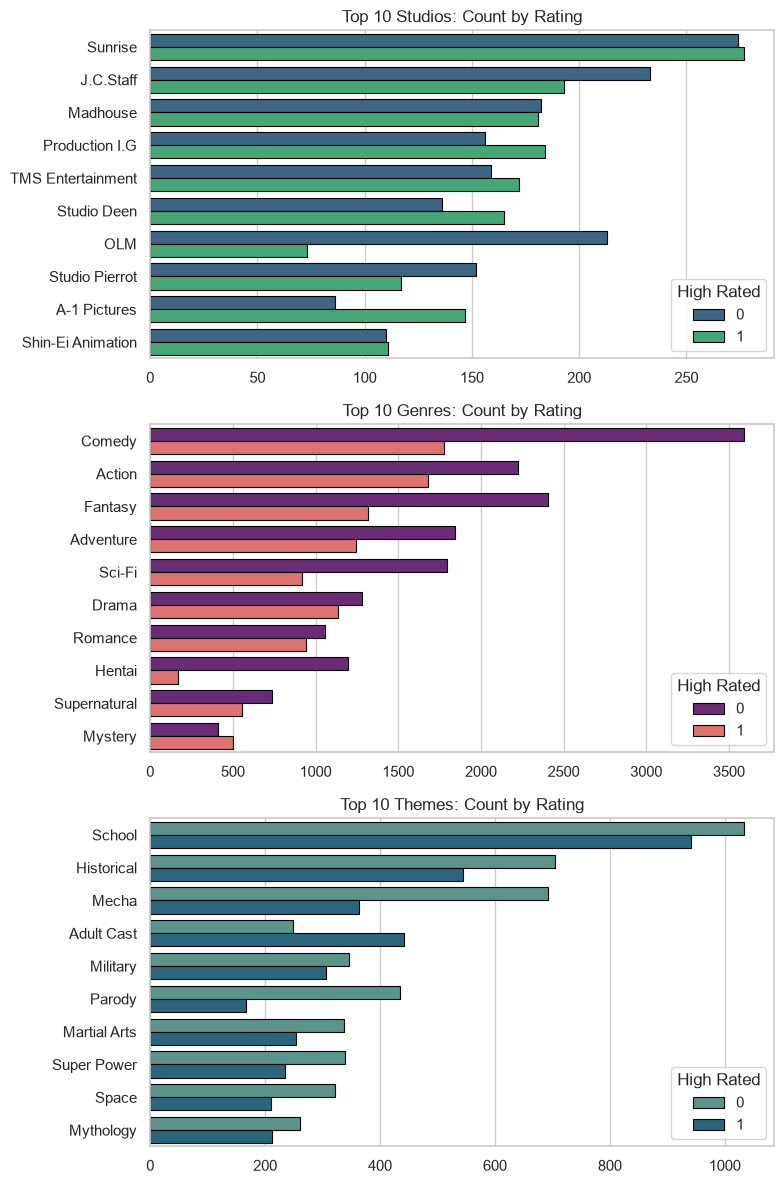

In [124]:
# Setup Figure
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

# studios top 10 vs high rated
plot_df_studios = dfc.explode('studios')
top_10_studios = plot_df_studios['studios'].value_counts().iloc[2:12].index
filtered_studios = plot_df_studios[plot_df_studios['studios'].isin(top_10_studios)]

sns.countplot(
    data=filtered_studios, 
    y='studios', 
    hue='high_rated', 
    order=top_10_studios, 
    ax=axes[0], 
    palette='viridis', 
    edgecolor='black', 
    linewidth=0.8
)
axes[0].set_title('Top 10 Studios: Count by Rating')
axes[0].set_ylabel(None)
axes[0].set_xlabel(None)
axes[0].legend(title='High Rated')

# genres top 10 vs high rated
plot_df_genres = dfc.explode('genres')
top_10_genres = plot_df_genres['genres'].value_counts().iloc[:10].index
filtered_genres = plot_df_genres[plot_df_genres['genres'].isin(top_10_genres)]

sns.countplot(
    data=filtered_genres, 
    y='genres', 
    hue='high_rated', 
    order=top_10_genres, 
    ax=axes[1], 
    palette='magma', 
    edgecolor='black', 
    linewidth=0.8
)
axes[1].set_title('Top 10 Genres: Count by Rating')
axes[1].set_ylabel(None)
axes[1].set_xlabel(None)
axes[1].legend(title='High Rated')

# themes top 10 vs high rated
plot_df_themes = dfc.explode('themes')
top_10_themes = plot_df_themes['themes'].value_counts().iloc[1:11].index 
filtered_themes = plot_df_themes[plot_df_themes['themes'].isin(top_10_themes)]

sns.countplot(
    data=filtered_themes, 
    y='themes', 
    hue='high_rated', 
    order=top_10_themes, 
    ax=axes[2], 
    palette='crest', 
    edgecolor='black', 
    linewidth=0.8
)
axes[2].set_title('Top 10 Themes: Count by Rating')
axes[2].set_ylabel(None)
axes[2].set_xlabel(None)
axes[2].legend(title='High Rated')

plt.tight_layout()
plt.show()   

#### Observation:
- `duration_mins` are cluster around `24-27 min` for high rated anime and low rated duration is more spread out.
- `episodes` count is balance with some outliers for low rated anime other wise balance.
- All Categorical features are approximately balance for both.

In [126]:
dfc.to_csv('../data/anime_dataset_clean.csv',index=False)